In [1]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("C:/Datasets/income.csv")
df

,Name,Age,Income($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000
5,Gautam,39,155000
6,David,41,160000
7,Andrea,38,162000
8,Brad,36,156000
9,Angelina,35,130000


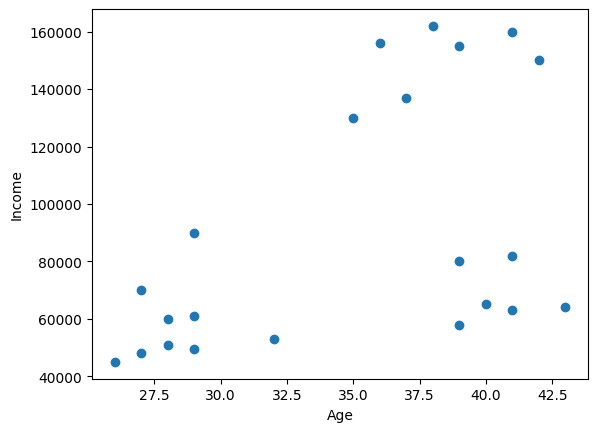

In [12]:
plt.scatter(df["Age"], df["Income($)"])
plt.xlabel("Age")
plt.ylabel("Income")
plt.show()

In [6]:
from sklearn.cluster import KMeans
km = KMeans(n_clusters = 3)
y_predicted = km.fit_predict(df[["Age", "Income($)"]])
y_predicted

array([2, 2, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0],
      dtype=int32)

In [7]:
df["cluster"] = y_predicted
df.head()

,Name,Age,Income($),cluster
0,Rob,27,70000,2
1,Michael,29,90000,2
2,Mohan,29,61000,0
3,Ismail,28,60000,0
4,Kory,42,150000,1


In [8]:
print(km.cluster_centers_)

[[3.29090909e+01 5.61363636e+04]
 [3.82857143e+01 1.50000000e+05]
 [3.40000000e+01 8.05000000e+04]]


In [10]:
x = km.cluster_centers_[:, 0]
y = km.cluster_centers_[:, 1]

In [11]:
df1 = df[df.cluster == 0]
df2 = df[df.cluster == 1]
df3 = df[df.cluster == 2]

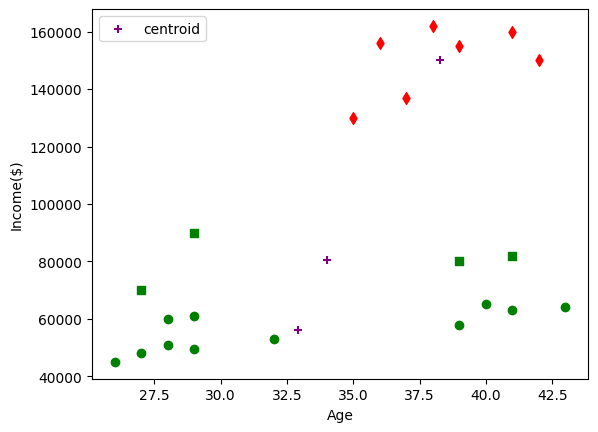

In [13]:
plt.scatter(df1.Age, df1["Income($)"], color = "green", marker = "o")
plt.scatter(df2.Age, df2["Income($)"], color = "red", marker = "d")
plt.scatter(df3.Age, df3["Income($)"], color = "green", marker = "s")
plt.scatter(x, y, color = "purple", marker = "+", label = "centroid")
plt.xlabel("Age")
plt.ylabel("Income($)")
plt.legend()
plt.show()

In [14]:
scaler = MinMaxScaler()
scaler.fit(df[["Income($)"]])
df["Income($)"] = scaler.transform(df[["Income($)"]])
scaler.fit(df[["Age"]])
df["Age"] = scaler.transform(df[["Age"]])

In [15]:
df.head()

,Name,Age,Income($),cluster
0,Rob,0.058824,0.213675,2
1,Michael,0.176471,0.384615,2
2,Mohan,0.176471,0.136752,0
3,Ismail,0.117647,0.128205,0
4,Kory,0.941176,0.897436,1


In [18]:
sse = []
k_rng = range(1, 10)
for k in k_rng:
    km = KMeans(n_clusters = k)
    km.fit(df[["Age", "Income($)"]])
    sse.append(km.inertia_)

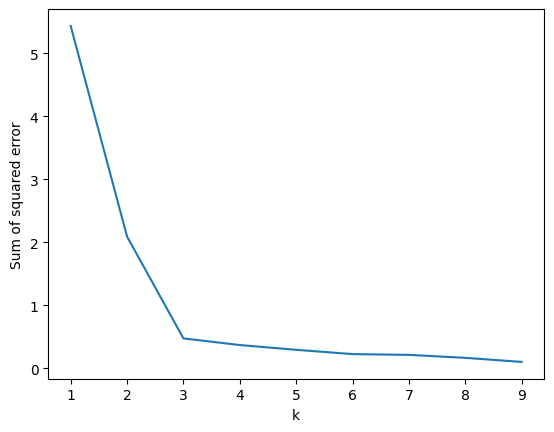

In [19]:
plt.xlabel("k")
plt.ylabel("Sum of squared error")
plt.plot(k_rng, sse)
plt.show()